# Informe técnico — Pipeline DataOps
## Sistema de Clasificación de Aprobación de Préstamos (Proyecto LACDA)

**Asignatura:** ITY1101 — Gestión de Datos para IA, DUOC UC · Evaluación Parcial N°2
**Equipo — Grupo 4:**

| Integrante | Rol |
|---|---|
| Nicolás Fernández Vera | Data Engineer |
| Bastián Gutiérrez | Data Analyst |
| Víctor Gutiérrez | ML Engineer |

**Repositorio:** https://github.com/Zzzhenda/Proyecto-LACDA

---

## Índice

1. [Resumen ejecutivo](#1)
2. [Arquitectura del pipeline](#2)
3. [El dataset](#3)
4. [Etapa 1 — Ingesta](#4)
5. [Etapa 2 — Monitoreo de calidad (KPIs con alertas)](#5)
6. [Etapa 3 — Limpieza](#6)
7. [Etapa 4 — Transformación](#7)
8. [Etapa 5 — Validación estructural y semántica + Carga](#8)
9. [Evidencias de automatización](#9)
10. [Manejo de anomalías y escalabilidad](#10)
11. [Conclusiones y próximos pasos](#11)

> **Cómo ejecutar este notebook:** requiere haber corrido el pipeline al menos una vez
> (`docker compose up`) y tener la base de datos arriba (`docker compose up -d db`).
> Dependencias locales: `pip install pandas sqlalchemy psycopg2-binary matplotlib`.


<a id="1"></a>
## 1. Resumen ejecutivo

**El problema.** Una institución financiera necesita decidir si aprueba o rechaza solicitudes
de préstamo. Para construir un modelo de IA que prediga el *default* crediticio se requieren
datos confiables, pero la fuente cruda (45.000 solicitudes, 14 variables) llega con anomalías:
edades imposibles (hasta 144 años), outliers extremos de ingreso y posibles inconsistencias
semánticas (experiencia laboral mayor que la edad, por ejemplo). Entrenar un modelo sobre esos
datos produciría decisiones de crédito erróneas, con costo directo para el negocio.

**La solución DataOps.** Un pipeline automatizado y reproducible de **5 etapas** que convierte
el dato crudo en un dataset validado y trazable, listo para Machine Learning:

```
ingesta → qualitycheck (KPI) → limpieza → transformación → validación + carga
```

A diferencia del enfoque tradicional (limpieza manual en planillas o scripts sueltos, sin
control de versiones ni validación), cada corrida del pipeline es **idéntica, auditable y
verificada**: el código vive en GitHub, corre en Docker, el CI lo ejecuta en cada cambio, y un
*gate* de validación impide que datos defectuosos lleguen a la base de datos.

**El valor para la organización:**

* **Confianza:** a la base de datos solo llegan datos que pasaron todas las reglas del contrato.
* **Trazabilidad:** logs por etapa y `fecha_carga` en cada fila permiten auditar cualquier corrida.
* **Detección temprana:** el KPI de calidad alerta si la fuente se degrada, antes de que el
  problema llegue a un modelo en producción.
* **Velocidad:** re-procesar todo el dataset toma menos de un minuto; incorporar un cambio de
  regla de negocio es editar un solo lugar (el contrato en `scripts/ingesta.py`).


<a id="2"></a>
## 2. Arquitectura del pipeline

Un script por etapa — la estructura del repo **es** el pipeline. La decisión de diseño central:
**la base de datos es el destino del pipeline, no su área de trabajo**. Las etapas intermedias
intercambian datos vía CSV en `data/`, y solo el dataset final —ya validado— se carga en una
**única tabla** PostgreSQL (`loan_data`).

```
data/loan_data.csv (fuente versionada en git)
        │
        ▼
[1. ingesta.py]        define el CONTRATO de datos y verifica estructura
        │              → data/loan_data_raw.csv (staging)
        ▼
[2. qualitycheck.py]   KPI 0-100 con alertas (monitoreo, no rompe el build)
        │
        ▼
[3. limpieza.py]       aplica el contrato: duplicados, nulos, rangos, dominios
        │              → data/loan_data_clean.csv
        ▼
[4. transformacion.py] 3 features derivadas → data/loan_data_transformed.csv
        │
        ▼
[5. validacion.py]     gate estructural + semántico (exit 1 si falla)
        │              └─ si TODO pasa → CARGA: TRUNCATE + INSERT transaccional
        ▼                                en la tabla loan_data (PostgreSQL)
```

**Dos decisiones de diseño que ordenan todo el proyecto:**

* **El contrato de datos vive en la puerta de entrada** (`ingesta.py` define `COLUMNAS`,
  `RANGOS`, `DOMINIOS`). La limpieza lo **aplica** y la validación lo **audita** importando
  las mismas constantes — una sola fuente de verdad, imposible que se desincronicen.
* **La carga vive dentro de la validación**: cargar la BD es la consecuencia directa de pasar
  el gate. Si una regla falla, el script sale con `exit 1` y la BD no se toca.

**Por qué una sola tabla** (y no tablas intermedias `raw`/`clean`/`transformed` en la BD):

* *Simplicidad:* un único contrato de esquema que mantener (`db/init.sql`).
* *Eficiencia:* una sola escritura a la BD por corrida en lugar de seis.
* *Garantía de calidad:* la tabla nunca contiene datos sin validar; los estados intermedios
  quedan como CSVs inspeccionables en `data/`.

**Herramientas y justificación:**

| Etapa | Herramienta | Justificación | Alternativa evaluada |
|---|---|---|---|
| Todas | Python 3.12 + pandas | Estándar de facto para procesamiento tabular; el dataset (45k filas) cabe cómodo en memoria | Spark: sobredimensionado para este volumen |
| Carga | PostgreSQL 16 + SQLAlchemy | BD relacional robusta y open source; tipado fuerte como segunda línea de validación | SQLite: sin servidor ni concurrencia; MySQL: menos tipos |
| Empaquetado | Docker Compose | Reproducibilidad total: la demo corre igual en cualquier máquina; healthcheck garantiza que la app espere a la BD | Instalación nativa (frágil, "en mi máquina funciona") |
| CI/CD | GitHub Actions | Ejecuta el pipeline completo en cada push/PR; un fallo de validación marca el build en rojo | Jenkins: requiere servidor propio |
| Seguimiento | GitHub (repo + commits) | Trazabilidad del trabajo del equipo integrada al código | Trello/Jira: separado del código |


<a id="3"></a>
## 3. El dataset

**Loan Approval Classification Dataset** — 45.000 solicitudes de préstamo, 14 variables
(descritas en `data/Metadata.txt`). La variable objetivo es `loan_status`
(1 = default, 0 = pagado).


In [1]:
import os
import sys
from pathlib import Path

import pandas as pd

# El notebook reutiliza los modulos del pipeline
sys.path.insert(0, str((Path.cwd() / ".." / "scripts").resolve()))

# Fuera de Docker, Postgres esta expuesto en localhost:5432
os.environ.setdefault("DB_HOST", "localhost")

DATA = Path("..") / "data"
pd.set_option("display.max_columns", None)

df_fuente = pd.read_csv(DATA / "loan_data.csv")
print(f"Fuente: {df_fuente.shape[0]} filas x {df_fuente.shape[1]} columnas")
df_fuente.head()

Fuente: 45000 filas x 14 columnas


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


Las estadísticas descriptivas del dato **crudo** muestran por qué la limpieza es necesaria —
nótese el máximo de `person_age` (144 años) y la cola extrema de `person_income`:


In [2]:
df_fuente.describe().round(2)

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.00,45000.00,45000.00,45000.00,45000.00,45000.00,45000.00,45000.00,45000.00
mean,27.76,80319.05,5.41,9583.16,11.01,0.14,5.87,632.61,0.22
std,6.05,80422.50,6.06,6314.89,2.98,0.09,3.88,50.44,0.42
min,20.00,8000.00,0.00,500.00,5.42,0.00,2.00,390.00,0.00
25%,24.00,47204.00,1.00,5000.00,8.59,0.07,3.00,601.00,0.00
50%,26.00,67048.00,4.00,8000.00,11.01,0.12,4.00,640.00,0.00
75%,30.00,95789.25,8.00,12237.25,12.99,0.19,8.00,670.00,0.00
max,144.00,7200766.00,125.00,35000.00,20.00,0.66,30.00,850.00,1.00


<a id="4"></a>
## 4. Etapa 1 — Ingesta (`scripts/ingesta.py`)

**Qué hace.** Define el **contrato de datos** del pipeline (las 14 columnas, los rangos duros y
los dominios categóricos, según `data/Metadata.txt`), lee la fuente (`data/loan_data.csv`),
verifica su **estructura** contra ese contrato y deja un snapshot en la zona de *staging*
(`data/loan_data_raw.csv`).

**Controles de entrada** (si alguno falla, el script sale con `exit 1` y el pipeline se detiene):

* el archivo fuente existe y no está vacío;
* están exactamente las 14 columnas del contrato — ni una más, ni una menos.

**Justificación.** Dos decisiones aquí:

* **El contrato vive en la puerta de entrada.** `limpieza.py` y `validacion.py` importan las
  mismas constantes (`RANGOS`, `DOMINIOS`) — un cambio de regla se hace en un solo lugar.
* **El staging desacopla la fuente del pipeline:** las etapas siguientes nunca tocan el archivo
  original, y si mañana la fuente pasa a ser una API o un bucket S3, solo cambia esta etapa.
  El chequeo estructural detiene de inmediato un cambio de esquema del proveedor (columna
  renombrada, columna nueva), el modo de fallo más común en pipelines de datos.


In [3]:
from ingesta import COLUMNAS

df_raw = pd.read_csv(DATA / "loan_data_raw.csv")
assert list(df_raw.columns) == COLUMNAS, "estructura del staging no coincide con el contrato"
print(f"Staging OK: {len(df_raw)} filas con las {len(COLUMNAS)} columnas canonicas del contrato")

Staging OK: 45000 filas con las 14 columnas canonicas del contrato


<a id="5"></a>
## 5. Etapa 2 — Monitoreo de calidad: KPIs con alertas (`scripts/qualitycheck.py`)

**Qué hace.** Mide la calidad del dato **crudo** justo después de la ingesta y *antes* de
limpiarlo. Es el sistema de monitoreo del pipeline: el dato crudo se espera sucio, así que esta
etapa **no rompe el build** — deja un KPI trazable por corrida.

**El KPI:** score 0–100 ponderado por 4 dimensiones de calidad. Cada dimensión penaliza
proporcionalmente al **% de filas afectadas**, lo que hace el indicador cuantificable y
comparable entre corridas:

| Dimensión | Peso | Qué mide |
|---|---|---|
| Nulos / faltantes | 0.30 | % de celdas vacías |
| Duplicados | 0.20 | % de filas repetidas exactas |
| Outliers | 0.20 | % de filas con algún valor fuera de IQR ± 1.5 |
| Inconsistencias | 0.30 | % de filas que violan reglas semánticas (ingreso < 0, experiencia > edad − 18, …) |

**Sistema de alertas por umbral:**

| Nivel | Condición | Acción |
|---|---|---|
| 🟢 OK | score ≥ 70 | Continuar; registrar el score para la serie histórica |
| 🟡 WARNING | 50 ≤ score < 70 | Continuar, pero investigar la dimensión degradada antes de la próxima corrida |
| 🔴 CRITICAL | score < 50 | Detener análisis aguas abajo y revisar la fuente con el proveedor de datos |

**Justificación — por qué medir ANTES de limpiar.** Si el KPI se midiera después de la
limpieza, daría siempre ~100 y no aportaría información. Medido sobre el dato crudo, una caída
del score entre corridas significa que **la fuente se degradó** — observabilidad que un gate de
pasa/no-pasa no entrega. Por eso monitoreo (etapa 2, informativa) y validación (etapa 5, gate
duro) son etapas separadas.


In [4]:
from qualitycheck import PESOS, QualityCheck, nivel_alerta

score, dims = QualityCheck(df_raw).quality_score()
print(f"QUALITY SCORE = {score}/100  ->  nivel {nivel_alerta(score)}")
pd.DataFrame({"% filas afectadas": dims, "peso": PESOS}).round(2)

QUALITY SCORE = 93.14/100  ->  nivel OK


,% filas afectadas,peso
nulos/faltantes,0.00,0.3
duplicados,0.00,0.2
outliers,34.31,0.2
inconsistencias,0.00,0.3


El dato crudo de esta fuente es estructuralmente sano (sin nulos ni duplicados) pero con una
proporción alta de outliers — exactamente lo que la etapa de limpieza debe tratar.


<a id="6"></a>
## 6. Etapa 3 — Limpieza (`scripts/limpieza.py`)

**Qué hace.** Aplica el contrato de datos sobre el staging y produce
`data/loan_data_clean.csv`. La secuencia, **en orden deliberado**:

1. **Duplicados exactos** → se eliminan (única operación que reduce filas).
2. **Nulos** → imputación con mediana (numéricas) / moda (categóricas). *Por qué imputar y no
   eliminar:* descartar una fila de 14 valores por una celda vacía pierde información útil; la
   mediana y la moda son robustas a outliers.
3. **Rangos duros** → `clip` a los límites del contrato. *Por qué clip y no eliminar:* una edad
   de 144 es un error de captura de un dato real; acotarlo conserva la fila.
4. **Reglas cruzadas** → `person_emp_exp ≤ person_age − 18` y `cred_hist_length ≤ person_age`,
   aplicadas con el `person_age` **ya corregido**. Si se aplicaran antes del paso 3, ajustar la
   edad después rompería la consistencia (bug real detectado en una versión anterior).
5. **Dominios categóricos** → valores fuera del dominio cerrado se reemplazan por la moda.
6. **Winsorización al 5%** → solo sobre `person_income` y `loan_amnt`, las columnas **sin** rango
   duro. Winsorizar una columna con contrato estricto (p. ej. `credit_score` ∈ [300, 850])
   destruiría valores legítimos.

El contrato que esta etapa aplica — y que la validación auditará después — es:


In [5]:
from ingesta import DOMINIOS, RANGOS
from limpieza import WINSORIZE_COLS

print("Rangos duros:")
display(pd.DataFrame([(c, lo, hi) for c, (lo, hi) in RANGOS.items()],
                     columns=["columna", "min", "max"]))
print("Dominios categoricos cerrados:")
for col, dom in DOMINIOS.items():
    print(f"  {col}: {sorted(dom)}")
print(f"\nColumnas winsorizadas al 5%: {WINSORIZE_COLS}")

Rangos duros:


,columna,min,max
0,person_age,18,100
1,credit_score,300,850
2,loan_int_rate,5,30
3,loan_percent_income,0,1


Dominios categoricos cerrados:
  person_gender: ['female', 'male']
  person_education: ['Associate', 'Bachelor', 'Doctorate', 'High School', 'Master']
  person_home_ownership: ['MORTGAGE', 'OTHER', 'OWN', 'RENT']
  loan_intent: ['DEBTCONSOLIDATION', 'EDUCATION', 'HOMEIMPROVEMENT', 'MEDICAL', 'PERSONAL', 'VENTURE']
  previous_loan_defaults_on_file: ['No', 'Yes']

Columnas winsorizadas al 5%: ['person_income', 'loan_amnt']


**Efecto de la limpieza** — comparación crudo vs. limpio:


In [6]:
df_clean = pd.read_csv(DATA / "loan_data_clean.csv")

cols = ["person_age", "person_emp_exp", "person_income", "loan_amnt"]
pd.DataFrame({
    "crudo min": df_raw[cols].min(), "crudo max": df_raw[cols].max(),
    "limpio min": df_clean[cols].min(), "limpio max": df_clean[cols].max(),
}).round(1)

,crudo min,crudo max,limpio min,limpio max
person_age,20.0,144.0,20.0,100.0
person_emp_exp,0.0,125.0,0.0,82.0
person_income,8000.0,7200766.0,28366.7,166754.7
loan_amnt,500.0,35000.0,2000.0,24000.0


<a id="7"></a>
## 7. Etapa 4 — Transformación (`scripts/transformacion.py`)

**Qué hace.** Agrega 3 features derivadas determinísticas al dataset limpio y produce
`data/loan_data_transformed.csv`, el dataset final del pipeline.

| Feature | Fórmula | Qué captura |
|---|---|---|
| `rate_x_pct_income` | `loan_int_rate × loan_percent_income` | Riesgo combinado: tasa alta **y** carga alta sobre el ingreso |
| `loan_burden` | `loan_amnt × (1 + tasa/100) / person_income` | Costo total del préstamo como fracción del ingreso anual |
| `has_prev_defaults` | `previous_loan_defaults_on_file == "Yes" → 1/0` | Historial de incumplimiento, en forma numérica |

**Justificación cuantitativa** — la correlación absoluta de cada variable con la variable
objetivo, calculada en vivo sobre el dataset final:


,|corr| con loan_status
has_prev_defaults,0.543
rate_x_pct_income,0.457
loan_percent_income,0.385
loan_burden,0.367
loan_int_rate,0.332
person_income,0.241
loan_amnt,0.108
person_age,0.021
person_emp_exp,0.020
cb_person_cred_hist_length,0.015


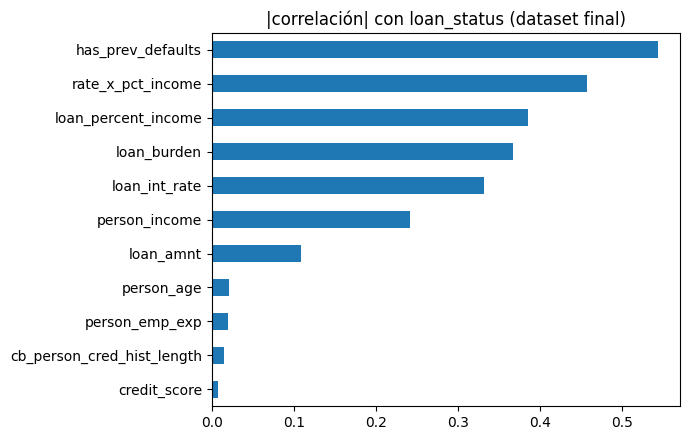

In [7]:
df_t = pd.read_csv(DATA / "loan_data_transformed.csv")

corr = (df_t.select_dtypes("number").corr()["loan_status"]
        .drop("loan_status").abs().sort_values(ascending=False))
ax = corr.plot.barh(figsize=(7, 4.5), title="|correlación| con loan_status (dataset final)")
ax.invert_yaxis()
ax.figure.tight_layout()
corr.round(3).to_frame("|corr| con loan_status")

Las 3 features derivadas quedan entre los predictores más fuertes del dataset
(`has_prev_defaults` es el N°1). Dos decisiones de **alcance** igual de importantes que las
features creadas:

* **No** se crean features sobre `credit_score` ni `person_age`: su correlación con
  `loan_status` es < 0.03 — agregarlas sería complejidad sin evidencia.
* El *encoding* del resto de categóricas y el escalado de numéricas se **delegan al pipeline de
  sklearn** de la fase de modelado: hacerlo aquí, sobre el dataset completo, filtraría
  información del set de test al de entrenamiento (*data leakage*).


<a id="8"></a>
## 8. Etapa 5 — Validación estructural y semántica + Carga (`scripts/validacion.py`)

**Qué hace.** Audita el dataset final contra el **mismo contrato** que definió la ingesta y
aplicó la limpieza (todos importan las mismas constantes — no pueden desincronizarse). Es el
**gate de calidad** del pipeline, y la **carga es la consecuencia de pasarlo**: si una sola
regla falla, el script sale con `exit 1`, **la base de datos no se toca** y el CI se marca en
rojo. Solo si todo pasa, el mismo paso ejecuta la carga.

* **Validación estructural:** están todas las columnas (14 del contrato + 3 derivadas); cero nulos.
* **Validación semántica:** rangos duros, `person_income ≥ 0`, `loan_amnt > 0`, reglas cruzadas
  de consistencia, dominios categóricos cerrados, `loan_status ∈ {0,1}`, features derivadas sin
  negativos.
* **Carga (si el gate pasa):** `TRUNCATE + INSERT` dentro de **una transacción** sobre la tabla
  única `loan_data` — re-correr nunca duplica datos, y un fallo a mitad de camino revierte todo.
  El conteo post-carga debe coincidir con el CSV (si no, `exit 1`), y la columna `fecha_carga`
  deja la trazabilidad de cada corrida.

**Diferencia con la etapa 2:** el qualitycheck mide el dato *crudo* (se espera sucio → informa);
la validación audita el dato *ya procesado* (cualquier violación es un **bug del pipeline** →
rompe el build). Demo en vivo del gate:


In [8]:
from validacion import validar_estructura, validar_features, validar_semantica

fallos = validar_estructura(df_t)
if not fallos:
    fallos += validar_semantica(df_t) + validar_features(df_t)

if fallos:
    print(f"VALIDACION FALLIDA ({len(fallos)} reglas violadas) -> la BD no se toca:")
    for f in fallos:
        print(f"  - {f}")
else:
    print(f"VALIDACION OK: las {len(df_t)} filas cumplen todas las reglas -> se ejecuta la carga.")

VALIDACION OK: las 45000 filas cumplen todas las reglas -> se ejecuta la carga.


Consulta en vivo a la base de datos — el resultado final del pipeline:


In [9]:
from sqlalchemy import text

from validacion import get_engine

engine = get_engine()
with engine.connect() as conn:
    resumen = pd.read_sql(text("""
        SELECT COUNT(*) AS filas,
               SUM(loan_status) AS defaults,
               COUNT(*) - SUM(loan_status) AS pagados,
               MAX(fecha_carga) AS ultima_carga
        FROM loan_data
    """), conn)
    muestra = pd.read_sql(text("SELECT * FROM loan_data ORDER BY id LIMIT 5"), conn)

display(resumen)
muestra

,filas,defaults,pagados,ultima_carga
0,45000,10000,35000,2026-06-10 01:58:24.252518


,id,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,cb_person_cred_hist_length,credit_score,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,previous_loan_defaults_on_file,loan_status,rate_x_pct_income,loan_burden,has_prev_defaults,fecha_carga
0,1,22.0,female,Master,71948.0,0,RENT,3.0,561,24000.0,PERSONAL,16.02,0.49,No,1,7.8498,0.3870,0,2026-06-10 01:58:24.252518
1,2,21.0,female,High School,28366.7,0,OWN,2.0,504,2000.0,EDUCATION,11.14,0.08,Yes,0,0.8912,0.0784,1,2026-06-10 01:58:24.252518
2,3,25.0,female,High School,28366.7,3,MORTGAGE,3.0,635,5500.0,MEDICAL,12.87,0.44,No,1,5.6628,0.2188,0,2026-06-10 01:58:24.252518
3,4,23.0,female,Bachelor,79753.0,0,RENT,2.0,675,24000.0,MEDICAL,15.23,0.44,No,1,6.7012,0.3468,0,2026-06-10 01:58:24.252518
4,5,24.0,male,Master,66135.0,1,RENT,4.0,586,24000.0,MEDICAL,14.27,0.53,No,1,7.5631,0.4147,0,2026-06-10 01:58:24.252518


<a id="9"></a>
## 9. Evidencias de automatización

**Flujo automatizado completo.** `docker compose up` levanta PostgreSQL (con healthcheck),
espera a que esté sana y ejecuta las 5 etapas encadenadas con `&&` — si una falla, las
siguientes no corren. El mismo flujo corre en **GitHub Actions** en cada push/PR a `main`
(`.github/workflows/ci.yml`): un fallo del gate de validación marca el build en rojo y los CSVs
procesados se publican como artifacts.

* **Código:** https://github.com/Zzzhenda/Proyecto-LACDA (scripts comentados, `Dockerfile`,
  `docker-compose.yml`, workflow de CI).
* **Logs de ejecución** de la última corrida completa (guardados en
  `docs/evidencias_pipeline.log`):


In [10]:
log = (Path("..") / "docs" / "evidencias_pipeline.log").read_text(encoding="utf-8")
print("\n".join(l for l in log.splitlines() if "lacda_app" in l))

 Container lacda_app Recreated
Attaching to lacda_app, lacda_db
 Container lacda_app Starting
 Container lacda_app Started
lacda_app  | [ingesta] 01:57:59 [INFO] === INICIO INGESTA ===
lacda_app  | [ingesta] 01:58:00 [INFO] Fuente leida: 45000 filas, 14 columnas
lacda_app  | [ingesta] 01:58:00 [INFO] Estructura OK: las 14 columnas del contrato estan presentes.
lacda_app  | [ingesta] 01:58:01 [INFO] Staging escrito: loan_data_raw.csv (45000 filas)
lacda_app  | [ingesta] 01:58:01 [INFO] === INGESTA OK ===
lacda_app  | [qualitycheck] 01:58:05 [INFO] === KPI DE CALIDAD SOBRE DATO CRUDO ===
lacda_app  | [qualitycheck] 01:58:06 [INFO]   [OK  ] nulos/faltantes      0.00% de filas afectadas (peso 0.3)
lacda_app  | [qualitycheck] 01:58:06 [INFO]   [OK  ] duplicados           0.00% de filas afectadas (peso 0.2)
lacda_app  | [qualitycheck] 01:58:06 [INFO]   [WARN] outliers            34.31% de filas afectadas (peso 0.2)
lacda_app  | [qualitycheck] 01:58:06 [INFO]   [OK  ] inconsistencias      0.0

<a id="10"></a>
## 10. Manejo de anomalías y escalabilidad

### Estrategia ante anomalías

| Anomalía | Detección | Diagnóstico | Corrección |
|---|---|---|---|
| La fuente cambia de esquema (columna renombrada/nueva) | Ingesta: chequeo estructural → `exit 1` inmediato | El log nombra exactamente las columnas faltantes/inesperadas | Actualizar el contrato en `ingesta.py` si el cambio es legítimo; reclamar al proveedor si no |
| La fuente se degrada (más nulos, más outliers) | KPI de la etapa 2 cae entre corridas; alerta WARNING/CRITICAL | La tabla de dimensiones indica **qué** dimensión se degradó | Ajustar reglas de limpieza o escalar al proveedor de datos |
| Datos inconsistentes sobreviven a la limpieza | Gate de validación → `exit 1`, la BD no se toca, CI en rojo | El log lista cada regla violada con conteo de filas | Corregir la regla en el contrato (`ingesta.py`, un solo lugar) y re-correr |
| Fallo de conexión a la BD | `depends_on + healthcheck` evita arrancar antes de tiempo; si la BD cae a mitad de carga, la transacción revierte | Logs del contenedor `lacda_db` | Re-correr la validación+carga: es idempotente, no deja estado a medias |
| Corrida interrumpida | Cualquier etapa es re-ejecutable | Logs por etapa con timestamps | Re-correr desde la etapa fallida: cada una lee su CSV de entrada |

### Escalabilidad

Con 45k filas el pipeline corre en menos de un minuto. Si el volumen creciera:

* **×10 (450k filas):** ya cubierto — la carga usa `chunksize=1000` y pandas maneja ese volumen
  en memoria sin cambios.
* **×100 (4.5M filas):** cambiar el staging CSV por **Parquet** (columnar, comprimido) y
  procesar por *chunks* con `pd.read_parquet`/`read_csv(chunksize=...)`; la arquitectura por
  etapas desacopladas no cambia.
* **×1000+ o flujo continuo:** reemplazar pandas por un motor distribuido (Spark/Dask)
  **solo en las etapas de limpieza/transformación** y orquestar con Airflow en lugar de `&&`;
  el contrato de datos, el gate de validación y la tabla destino se conservan tal cual.
  El diseño de staging desacoplado es precisamente lo que permite sustituir el motor de una
  etapa sin tocar las demás.


<a id="11"></a>
## 11. Conclusiones y próximos pasos

**Lo logrado.** Un pipeline DataOps completo, automatizado y verificable: la fuente cruda de
45.000 solicitudes se convierte —sin intervención manual— en una tabla PostgreSQL validada,
con monitoreo de calidad cuantificado (score 93/100 en la fuente actual), un gate que impide
cargar datos defectuosos, y CI que repite todo el proceso en cada cambio del código.

**Decisiones clave defendidas en este informe:**

1. **Un script por etapa** (los 5 de la metodología del curso): la estructura del repo es el
   pipeline, fácil de explicar y de demostrar etapa por etapa.
2. BD como destino con **tabla única** y la **carga dentro del gate de validación**
   (simplicidad + garantía de calidad).
3. **Contrato de datos definido en la ingesta** y reutilizado por limpieza y validación
   (una sola fuente de verdad).
4. Monitoreo (informativo, sobre dato crudo) separado de validación (gate duro, sobre dato final).
5. Features derivadas justificadas por correlación, y encoding/escalado delegados a la fase
   de modelado para evitar *data leakage*.

**Próximos pasos del proyecto:**

1. **Modelado:** entrenar clasificadores de default (regresión logística como baseline,
   luego árboles de gradiente) usando `loan_data` como fuente, con pipeline de sklearn para
   encoding/escalado dentro de la validación cruzada.
2. **Servicio:** exponer el modelo entrenado tras una API REST para scoring de solicitudes
   nuevas.
3. **Operación:** programar el pipeline con un orquestador (Airflow) y alimentar el KPI de
   calidad a un dashboard para seguimiento histórico.
